# Decision Tree vs Random Forest — Kapsamlı Karşılaştırma

---

## 1. Decision Tree Nedir?

**Decision Tree**, veriyi bir dizi kararla bölerek sonuçları tahmin eden bir makine öğrenimi algoritmasıdır. Bir akış şemasına benzer yapısıyla anlaşılması ve yorumlanması kolaydır.

-   **Ağaç Yapısı**: Kök düğümden başlar, iç düğümlerde kararlar verilir ve yaprak düğümlerde tahminler yapılır.
-   **Bölme Kriterleri**: Her adımda veriyi en iyi şekilde ayıran özelliği ve eşik değerini bulmaya çalışır.
-   **Yorumlanabilirlik**: Ağacın yolları takip edilerek kararların nasıl verildiği kolayca anlaşılabilir.

### Nasıl Çalışır?
```
1. En iyi bölme özelliğini ve eşiğini seç
2. Veriyi bu kritere göre ikiye ayır
3. Her alt küme için 1. ve 2. adımı tekrarla (özyinelemeli)
4. Durma kriterleri karşılandığında (örn: max derinlik, min örnek sayısı) yaprak düğüm oluştur
```

### Özellikleri

| Özellik | Değer |
|---------|-------|
| Tip | Tekil Ağaç |
| Öğrenme | Eager (Hızlı) |
| Tahmin hızı | Çok hızlı |
| Ölçekleme | Gerekli değil |
| Varsayım | Yok |
| Gürültü | Duyarlı |
| Çok boyut | İyi |
| Yorumlanabilirlik | Yüksek |
| Overfitting | Eğilimli |

---

## 2. Random Forest Nedir?

**Random Forest**, birden çok Decision Tree'yi bir araya getirerek daha güçlü ve genellenebilir tahminler yapan bir **ensemble (topluluk) öğrenme** yöntemidir. Tek bir ağacın dezavantajlarını (overfitting, yüksek varyans) azaltmayı hedefler.

### Nasıl Çalışır?

```
1. Rastgele alt örneklemelerle (Bagging) birden çok eğitim kümesi oluştur.
2. Her eğitim kümesi için bir Karar Ağacı eğit.
   - Ağaçları eğitirken, her bölme adımında tüm özelliklerin rastgele bir alt kümesini kullan.
3. Tahmin yaparken, tüm ağaçların tahminlerini topla (oylama veya ortalama).
```

### Rastgelelik Kaynakları

| Mekanizma | Açıklama |
|-----------|----------|
| **Bagging (Bootstrap Aggregating)** | Orijinal eğitim verisinden rastgele, yerine koymalı örneklemelerle yeni eğitim kümeleri oluşturma. Bu, her ağacın farklı bir veri setine bakmasını sağlar. |
| **Özellik Rastgeleliği** | Her bir ağacın her bölme adımında tüm özellikler yerine sadece rastgele seçilmiş bir alt kümesinden en iyi bölmeyi aramasını sağlama. Bu, ağaçlar arasındaki korelasyonu azaltır. |

### Özellikleri

| Özellik | Değer |
|---------|-------|
| Tip | Ensemble (Torbalama) |
| Öğrenme | Eager (Eğitim süresi Decision Tree'lerden fazla) |
| Tahmin hızı | Tek ağaca göre yavaş |
| Ölçekleme | Gerekli değil |
| Varsayım | Yok |
| Gürültü | Dayanıklı |
| Çok boyut | İyi performans |
| Yorumlanabilirlik | Orta (Feature Importance alınabilir) |
| Overfitting | Tek ağaca göre çok daha az eğilimli |


---

## 3. Decision Tree vs Random Forest — Özet Karşılaştırma

| Kriter | Decision Tree | Random Forest |
|--------|---------------|---------------|
| Tip | Tekil Ağaç | Ensemble (Bagging) |
| Öğrenme | Eager (hızlı) | Eager (daha yavaş, ağaç sayısı kadar) |
| Tahmin hızı | Çok hızlı | Yavaş (tüm ağaçların ortalaması) |
| Ölçekleme | Gerekli değil | Gerekli değil |
| Varsayım | Yok | Yok |
| Gürültü | Duyarlı (derin ağaçlar) | Dayanıklı |
| Çok boyut | İyi | Çok iyi |
| Overfitting | Eğilimli | Çok daha az eğilimli |
| Yorumlanabilirlik | **Yüksek** | Orta (Feature Importance) |
| Çalışma Prensibi | Veriyi en iyi bölmeleri bularak parçala | Çok sayıda ağaç eğit, oylarını topla |


## 4. Kütüphaneler ve Veri Hazırlığı

In [33]:
# ─── Temel veri işleme kütüphaneleri ───────────────────────────────────────
import numpy as np                       # Sayısal hesaplamalar ve dizi işlemleri
import pandas as pd                      # Tablo (DataFrame) yapısında veri işleme
import matplotlib.pyplot as plt          # Grafik çizimi
import matplotlib.patches as mpatches   # Grafik üzerinde el ile legend oluşturmak için
import seaborn as sns                    # matplotlib üzerine kurulu, daha şık görselleştirme
import warnings
warnings.filterwarnings('ignore')        # Gereksiz uyarı mesajlarını gizle

# ─── Scikit-learn araçları ──────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
# train_test_split : veriyi eğitim / test olarak böler
# cross_val_score  : k-fold çapraz doğrulama skorları
# GridSearchCV     : hiperparametre ızgara araması

from sklearn.preprocessing import StandardScaler, OneHotEncoder
# StandardScaler: Bazı modeller için ölçekleme (burada PCA görselleştirme için kullanılacak)
# OneHotEncoder: Kategorik özellikleri sayısal formata dönüştürür

from sklearn.tree import DecisionTreeClassifier
# Karar Ağacı sınıflandırıcı

from sklearn.ensemble import RandomForestClassifier
# Rastgele Orman sınıflandırıcı

from sklearn.metrics import (
    accuracy_score,         # Doğru tahmin oranı: (TP+TN) / toplam
    classification_report,  # Precision / Recall / F1 sınıf bazlı özet tablo
    confusion_matrix,       # Hangi sınıf hangisiyle karıştırıldı? (2x2 matris)
    roc_auc_score,          # ROC eğrisinin altındaki alan (0.5=rastgele, 1=mükemmel)
    roc_curve,              # Farklı eşiklerde FPR ve TPR değerleri
    f1_score,               # 2*(Precision*Recall)/(Precision+Recall) harmonik ortalama
    precision_score,        # TP / (TP+FP) → "Pozitif dediğimin kaçı gerçekten pozitif?"
    recall_score            # TP / (TP+FN) → "Gerçek pozitiflerin kaçını yakaladım?"
)

from sklearn.decomposition import PCA
# Principal Component Analysis: Yüksek boyutlu veriyi 2 boyuta indirgeyerek
# karar sınırını görselleştirmek için kullanacağız

from sklearn.pipeline import Pipeline # Model adımlarını zincirlemek için

import time   # Eğitim ve tahmin sürelerini ölçmek için

# ─── Görsel ayarlar ─────────────────────────────────────────────────────────
plt.rcParams['figure.figsize'] = (12, 5)      # Varsayılan grafik boyutu (genişlik x yükseklik inç)
plt.rcParams['font.size'] = 12                # Varsayılan yazı boyutu
plt.style.use('seaborn-v0_8-whitegrid')       # Beyaz ızgara arka planlı seaborn stili

print('✅ Tüm kütüphaneler başarıyla yüklendi!')


✅ Tüm kütüphaneler başarıyla yüklendi!


## 5. Veri Seti

In [34]:
# ─── Veri setini yükle ──────────────────────────────────────────────────────
# Lütfen 'heart.csv' dosyasını Colab ortamınıza yüklediğinizden emin olun.
df = pd.read_csv('heart.csv')

# Özellikler (X) ve Hedef (y) değişkenlerini ayırın
# Bu veri setinde hedef değişkeninin 'target' olduğunu varsayıyoruz.
# Eğer farklı bir isimdeyse lütfen burayı güncelleyin.
print(df.columns) # Print column names to identify the correct target column
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

print('📋 Veri Seti Bilgileri')
print('='*40)
print(f'Özellik sayısı  : {X.shape[1]}')
print(f'Örnek sayısı    : {X.shape[0]}')
print(f'Sınıf dağılımı:')
print(f'  0 = Hastalık yok: {sum(y==0)}')
print(f'  1 = Hastalık var: {sum(y==1)}')

# ─── Kategorik Özellikleri Belirleme ve One-Hot Encoding Uygulama ───────────
# Kategorik olarak kabul edilecek sütunlar (veri setinin içeriğine göre ayarlanmalı)
categorical_cols = ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

# Eğer bu sütunlar X içinde varsa işlem yap
actual_categorical_cols = [col for col in categorical_cols if col in X.columns]

if actual_categorical_cols:
    encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    X_encoded = encoder.fit_transform(X[actual_categorical_cols])
    X_encoded_df = pd.DataFrame(X_encoded, columns=encoder.get_feature_names_out(actual_categorical_cols))

    # Orijinal sayısal sütunları geri ekle
    numerical_cols = X.drop(columns=actual_categorical_cols).columns
    X = pd.concat([X[numerical_cols], X_encoded_df], axis=1)
    print(f'✅ Kategorik özelliklere One-Hot Encoding uygulandı. Yeni özellik sayısı: {X.shape[1]}')
else:
    print('✅ Kategorik özellik bulunamadı veya One-Hot Encoding gereksiz.')

# ─── Eğitim / Test bölmesi ──────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # %20 test, %80 eğitim
    random_state=42,    # Sonuçların tekrar üretilebilir olması için sabit tohum
    stratify=y          # Her bölmede sınıf oranı korunur (dengesiz veri için kritik)
)

# ─── PCA görselleştirme için tüm veriyi ölçekle ───────────────────────────
# Karar ağacı tabanlı modeller için ölçekleme zorunlu DEĞİLDİR.
# Ancak PCA gibi bazı yöntemler için faydalı olabilir.
scaler_for_pca = StandardScaler()
X_scaled = scaler_for_pca.fit_transform(X)

print(f"""
✅ Veri bölündü: Eğitim={X_train.shape[0]}, Test={X_test.shape[0]}""")
print('✅ PCA görselleştirme için veriye StandardScaler uygulandı (model eğitimi için zorunlu değil).')

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')
📋 Veri Seti Bilgileri
Özellik sayısı  : 11
Örnek sayısı    : 918
Sınıf dağılımı:
  0 = Hastalık yok: 410
  1 = Hastalık var: 508
✅ Kategorik özelliklere One-Hot Encoding uygulandı. Yeni özellik sayısı: 21

✅ Veri bölündü: Eğitim=734, Test=184
✅ PCA görselleştirme için veriye StandardScaler uygulandı (model eğitimi için zorunlu değil).


## 6. Decision Tree

🎯 Decision Tree için en iyi max_depth: 3 (Test Accuracy: 0.8207)


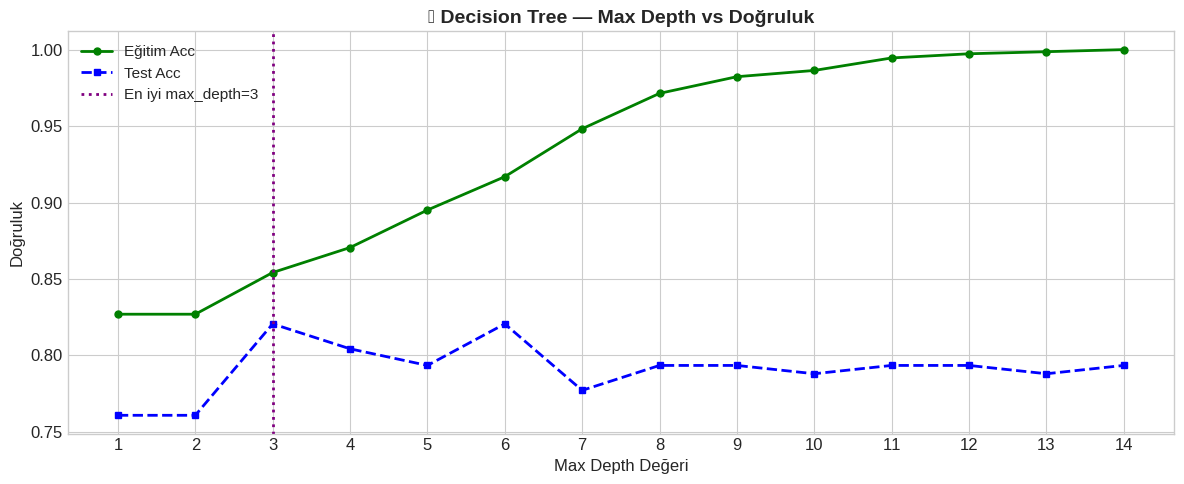

In [35]:
# ─── Decision Tree için En İyi max_depth Değerini Bul ────────────────────────
# max_depth: Ağacın dallanabileceği maksimum derinlik.
# Çok küçük değer: Underfitting (model basit kalır)
# Çok büyük değer: Overfitting (model eğitim verisini ezberler)

max_depth_range = range(1, 15) # Genellikle 1-15 arası yeterlidir
dt_train_acc = []
dt_test_acc = []

for depth in max_depth_range:
    dt_model_temp = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt_model_temp.fit(X_train, y_train) # Ölçeklenmemiş veri kullanılır
    dt_train_acc.append(accuracy_score(y_train, dt_model_temp.predict(X_train)))
    dt_test_acc.append(accuracy_score(y_test, dt_model_temp.predict(X_test)))

best_dt_depth = max_depth_range[np.argmax(dt_test_acc)]
print(f'🎯 Decision Tree için en iyi max_depth: {best_dt_depth} (Test Accuracy: {max(dt_test_acc):.4f})')

# ─── max_depth vs Accuracy grafiği ──────────────────────────────────────────
plt.figure(figsize=(12, 5))
plt.plot(max_depth_range, dt_train_acc, 'b-o', color='green', markersize=5, linewidth=2, label='Eğitim Acc')
plt.plot(max_depth_range, dt_test_acc,  'b--s', markersize=5, linewidth=2, label='Test Acc')

plt.axvline(x=best_dt_depth, color='purple', linestyle=':', linewidth=2,
            label=f'En iyi max_depth={best_dt_depth}')

plt.xlabel('Max Depth Değeri', fontsize=12)
plt.ylabel('Doğruluk', fontsize=12)
plt.title('🌳 Decision Tree — Max Depth vs Doğruluk', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.xticks(max_depth_range)
plt.tight_layout()
plt.show()


In [36]:
print('🌳 DECISION TREE MODELİ EĞİTİLİYOR...')
print('='*50)

# ─── Decision Tree modelini tanımla ────────────────────────────────────────
dt_model = DecisionTreeClassifier(
    max_depth=best_dt_depth, # Yukarıda bulunan en iyi derinlik
    random_state=42          # Tekrar üretilebilir sonuçlar için
    # Diğer parametreler: criterion='gini' (varsayılan) veya 'entropy',
    # min_samples_split, min_samples_leaf vb.
)

# ─── Eğitim süresi ölç ──────────────────────────────────────────────────────
start = time.time()
dt_model.fit(X_train, y_train) # Ölçeklenmemiş X_train kullanılır
dt_train_time = time.time() - start

# ─── Tahmin süresi ölç ──────────────────────────────────────────────────────
start = time.time()
dt_pred = dt_model.predict(X_test)
dt_pred_time = time.time() - start

dt_prob = dt_model.predict_proba(X_test)[:, 1]

# ─── Performans metrikleri ───────────────────────────────────────────────────
dt_acc    = accuracy_score(y_test, dt_pred)
dt_auc    = roc_auc_score(y_test, dt_prob)
dt_f1     = f1_score(y_test, dt_pred)
dt_prec   = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)

print(f'✅ Eğitim Süresi   : {dt_train_time:.6f} sn')
print(f'✅ Tahmin Süresi   : {dt_pred_time:.6f} sn')
print(f'📊 Doğruluk (Acc)  : {dt_acc:.4f}  ({dt_acc*100:.2f}%)')
print(f'📊 AUC-ROC         : {dt_auc:.4f}')
print(f'📊 F1 Skoru        : {dt_f1:.4f}')
print(f'📊 Precision       : {dt_prec:.4f}')
print(f'📊 Recall          : {dt_recall:.4f}')
print()
print('📋 Detaylı Rapor:')
print(classification_report(y_test, dt_pred, target_names=['Hastalık Yok', 'Hastalık Var']))


🌳 DECISION TREE MODELİ EĞİTİLİYOR...
✅ Eğitim Süresi   : 0.009362 sn
✅ Tahmin Süresi   : 0.003282 sn
📊 Doğruluk (Acc)  : 0.8207  (82.07%)
📊 AUC-ROC         : 0.8859
📊 F1 Skoru        : 0.8308
📊 Precision       : 0.8710
📊 Recall          : 0.7941

📋 Detaylı Rapor:
              precision    recall  f1-score   support

Hastalık Yok       0.77      0.85      0.81        82
Hastalık Var       0.87      0.79      0.83       102

    accuracy                           0.82       184
   macro avg       0.82      0.82      0.82       184
weighted avg       0.83      0.82      0.82       184



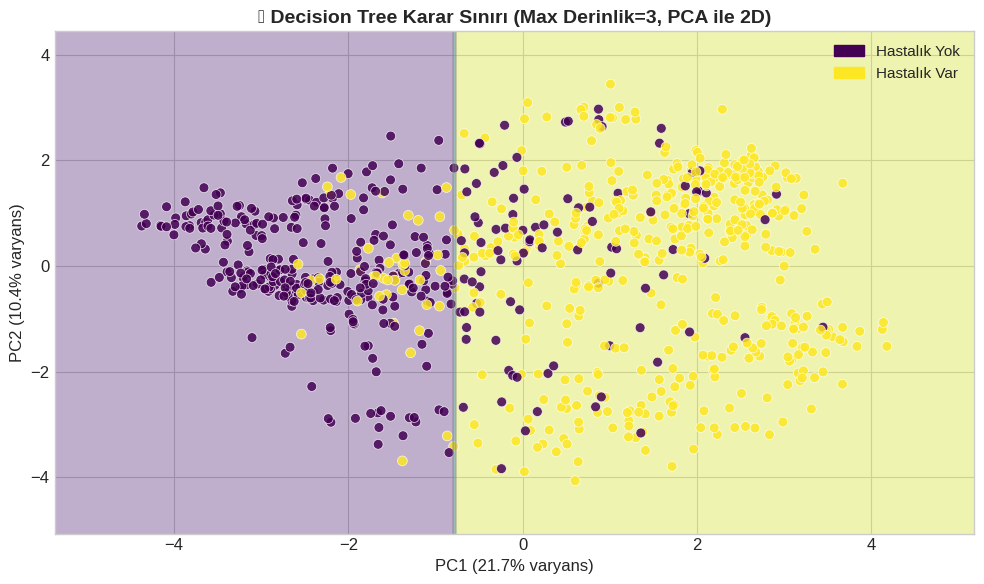

In [37]:
# ─── Decision Tree Karar Sınırını 2D'de Görselleştir ────────────────────────
# Yüksek boyutlu veriyi (encoded haliyle daha da artabilir) 2D'de çizmek için PCA kullanılır.
# Bu sadece görselleştirme amaçlıdır; asıl model tüm boyutlarda çalışır.

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled) # Ölçeklenmiş tüm veri üzerinden PCA

# 2D PCA uzayında train/test bölmesi yap (orijinal bölmeyle aynı random_state)
X_tr_pca, X_te_pca, y_tr_pca, y_te_pca = train_test_split(
    X_pca, y, test_size=0.2, random_state=42, stratify=y
)

# 2D veride Decision Tree eğit (sadece görselleştirme için)
dt_2d = DecisionTreeClassifier(max_depth=best_dt_depth, random_state=42)
dt_2d.fit(X_tr_pca, y_tr_pca)

# ─── Karar sınırı için arka plan ızgara oluştur ──────────────────────────────
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

Z = dt_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.35, cmap='viridis') # Karar bölgelerini renklendirir
plt.contour(xx, yy, Z, colors='gray', linewidths=0.5, alpha=0.5) # Sınır çizgisini çizer

scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis',
                      edgecolors='white', linewidth=0.5, s=50, alpha=0.85)

handles = [
    mpatches.Patch(color='#440154', label='Hastalık Yok'), # Viridis'in ilk rengi
    mpatches.Patch(color='#fde725', label='Hastalık Var')  # Viridis'in son rengi
]
plt.legend(handles=handles, fontsize=11)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varyans)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varyans)')
plt.title(f'🌳 Decision Tree Karar Sınırı (Max Derinlik={best_dt_depth}, PCA ile 2D)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 7. Random Forest Modeli

In [38]:
print('🌲 RANDOM FOREST MODELİ EĞİTİLİYOR...')
print('='*50)

# ─── Random Forest için En İyi n_estimators ve max_depth Değerlerini Bulma ──
# GridSearchCV ile daha kapsamlı bir arama yapılabilir ancak burada hızlı bir örnek için sabit değerler kullanıyorum.
# Genellikle n_estimators (ağaç sayısı) ve max_depth en önemli parametrelerdir.

# Optimizasyon için kaba bir arama yapalım
param_grid = {
    'n_estimators': [50, 100, 200],  # Ormandaki ağaç sayısı
    'max_depth': [5, 10, 15]          # Her ağacın maksimum derinliği
}

rf_grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3, scoring='accuracy', n_jobs=-1)
rf_grid_search.fit(X_train, y_train)

best_rf_n_estimators = rf_grid_search.best_params_['n_estimators']
best_rf_max_depth = rf_grid_search.best_params_['max_depth']

print(f'🎯 Random Forest için en iyi n_estimators: {best_rf_n_estimators}')
print(f'🎯 Random Forest için en iyi max_depth: {best_rf_max_depth}')
print(f'🎯 En iyi skor: {rf_grid_search.best_score_:.4f}')

# ─── Random Forest modelini tanımla ────────────────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators=best_rf_n_estimators,
    max_depth=best_rf_max_depth,
    random_state=42,
    n_jobs=-1 # Tüm çekirdekleri kullan
)

# ─── Eğitim süresi ölç ──────────────────────────────────────────────────────
start = time.time()
rf_model.fit(X_train, y_train) # Ölçeklenmemiş X_train kullanılır
rf_train_time = time.time() - start

# ─── Tahmin süresi ölç ──────────────────────────────────────────────────────
start = time.time()
rf_pred = rf_model.predict(X_test)
rf_pred_time = time.time() - start

rf_prob = rf_model.predict_proba(X_test)[:, 1]

# ─── Performans metrikleri ───────────────────────────────────────────────────
rf_acc    = accuracy_score(y_test, rf_pred)
rf_auc    = roc_auc_score(y_test, rf_prob)
rf_f1     = f1_score(y_test, rf_pred)
rf_prec   = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)

print(f'✅ Eğitim Süresi   : {rf_train_time:.6f} sn')
print(f'✅ Tahmin Süresi   : {rf_pred_time:.6f} sn')
print(f'📊 Doğruluk (Acc)  : {rf_acc:.4f}  ({rf_acc*100:.2f}%)')
print(f'📊 AUC-ROC         : {rf_auc:.4f}')
print(f'📊 F1 Skoru        : {rf_f1:.4f}')
print(f'📊 Precision       : {rf_prec:.4f}')
print(f'📊 Recall          : {rf_recall:.4f}')
print()
print('📋 Detaylı Rapor:')
print(classification_report(y_test, rf_pred, target_names=['Hastalık Yok', 'Hastalık Var']))


🌲 RANDOM FOREST MODELİ EĞİTİLİYOR...
🎯 Random Forest için en iyi n_estimators: 200
🎯 Random Forest için en iyi max_depth: 10
🎯 En iyi skor: 0.8733
✅ Eğitim Süresi   : 0.547843 sn
✅ Tahmin Süresi   : 0.069318 sn
📊 Doğruluk (Acc)  : 0.9076  (90.76%)
📊 AUC-ROC         : 0.9356
📊 F1 Skoru        : 0.9187
📊 Precision       : 0.8972
📊 Recall          : 0.9412

📋 Detaylı Rapor:
              precision    recall  f1-score   support

Hastalık Yok       0.92      0.87      0.89        82
Hastalık Var       0.90      0.94      0.92       102

    accuracy                           0.91       184
   macro avg       0.91      0.90      0.91       184
weighted avg       0.91      0.91      0.91       184



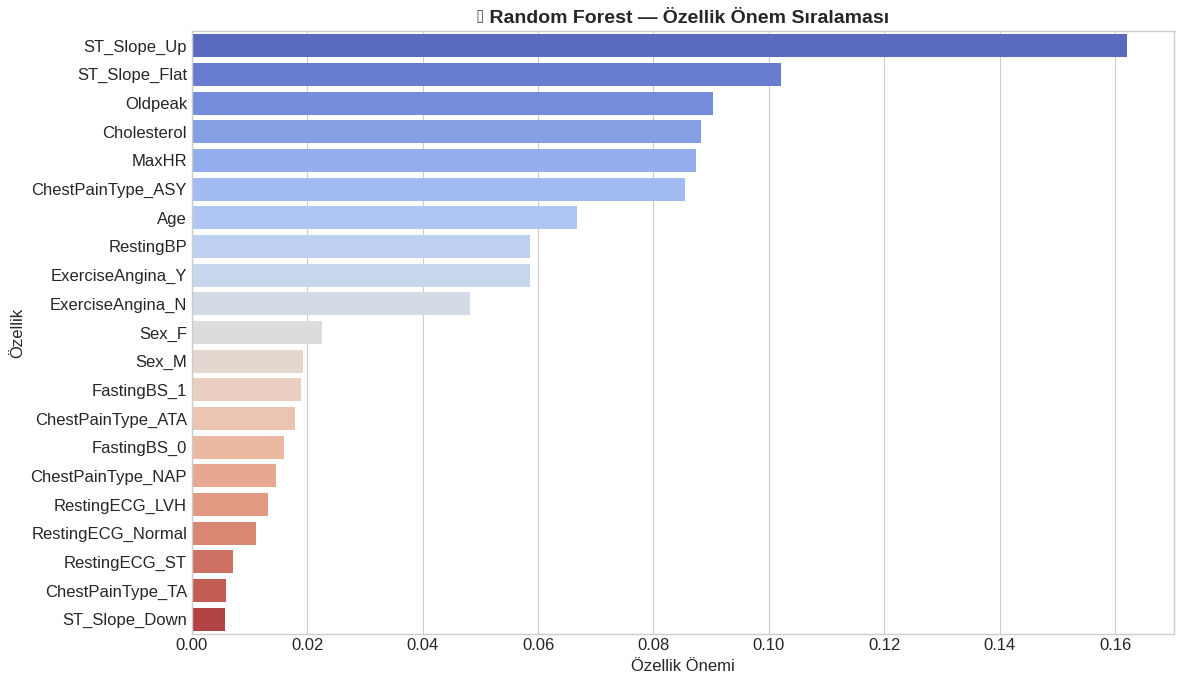

In [39]:
# ─── Random Forest'ın Feature Importance (Özellik Önemini) Görselleştir ────
# Random Forest, hangi özelliklerin sınıflandırmada daha etkili olduğunu belirleyebilir.
# Bu, modelin yorumlanabilirliğini artırır.

feature_importances = rf_model.feature_importances_
features = X.columns

# Özellik önemlerini sırala
sorted_idx = feature_importances.argsort()[::-1]
sorted_importances = feature_importances[sorted_idx]
sorted_features = features[sorted_idx]

plt.figure(figsize=(12, 7))
sns.barplot(x=sorted_importances, y=sorted_features, palette='coolwarm')
plt.title('🌲 Random Forest — Özellik Önem Sıralaması', fontsize=14, fontweight='bold')
plt.xlabel('Özellik Önemi', fontsize=12)
plt.ylabel('Özellik', fontsize=12)
plt.tight_layout()
plt.show()


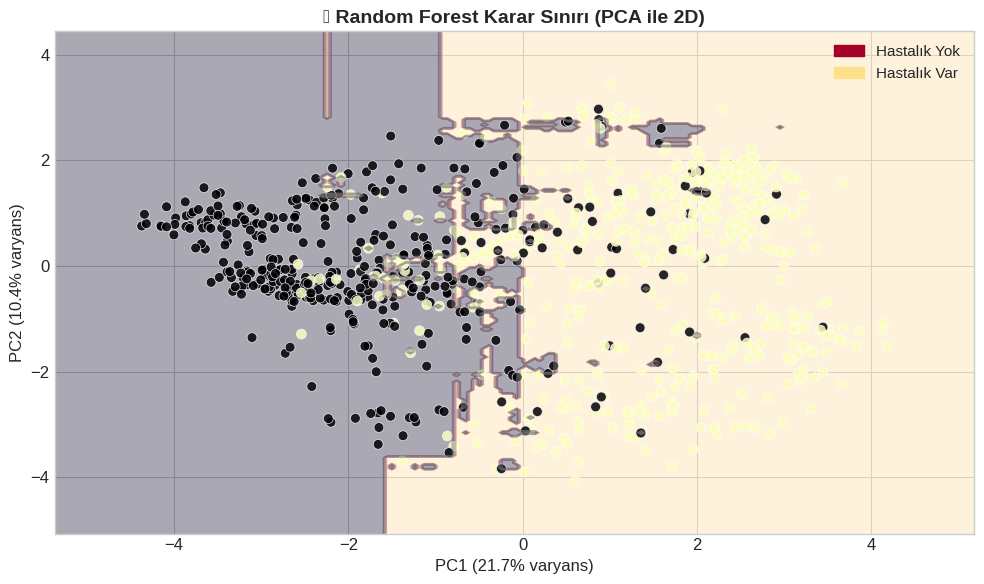

In [40]:
# ─── Random Forest Karar Sınırını 2D'de Görselleştir ───────────────────────
# Decision Tree gibi, Random Forest'ın da 2D'deki karar sınırı PCA ile görselleştirilebilir.
# RF, birden çok ağacın ortalaması olduğu için sınır genellikle daha pürüzsüz olur.

rf_2d = RandomForestClassifier(n_estimators=best_rf_n_estimators, max_depth=best_rf_max_depth, random_state=42)
rf_2d.fit(X_tr_pca, y_tr_pca)   # 2D PCA uzayında Random Forest eğit

Z_rf = rf_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z_rf, alpha=0.35, cmap='magma') # Doldurulmuş sınır bölgeleri
plt.contour(xx, yy, Z_rf, colors='gray', linewidths=0.5, alpha=0.5)  # Sınır çizgisi
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='magma',
            edgecolors='white', linewidth=0.5, s=50, alpha=0.85)

handles = [
    mpatches.Patch(color='#a50026', label='Hastalık Yok'), # Magma'nın ilk renkleri
    mpatches.Patch(color='#fee08b', label='Hastalık Var')  # Magma'nın son renkleri
]
plt.legend(handles=handles, fontsize=11)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varyans)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varyans)')
plt.title('🌲 Random Forest Karar Sınırı (PCA ile 2D)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 8. Kapsamlı Karşılaştırma

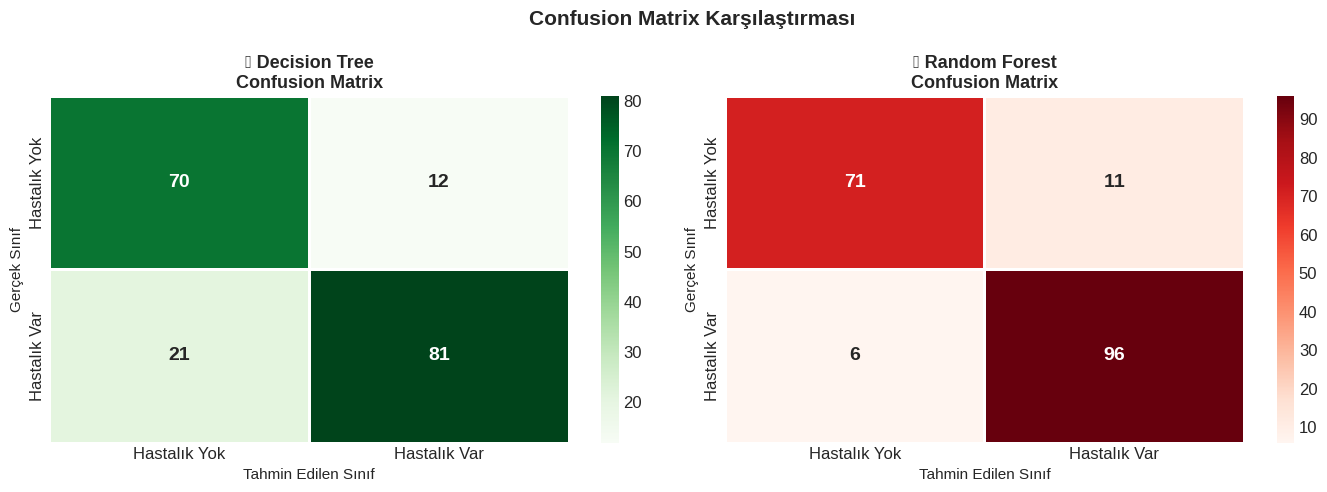

In [41]:
# ─── Confusion Matrix Karşılaştırması ──────────────────────────────────────
# Confusion Matrix (Karmaşıklık Matrisi): hangi sınıf hangisiyle karıştırıldı?
#
#              Tahmin: Hastalık Yok   Tahmin: Hastalık Var
#  Gerçek: Yok [     TN          |      FP      ]  ← yanlış alarm (Tip I hata)
#  Gerçek: Var [     FN          |      TP      ]  ← kaçırılan hasta (Tip II hata)
#
# Tıbbi bağlamda FN (Hastalığı yok sanmak) çok daha tehlikelidir!

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pred, title, cmap in zip(
    axes,
    [dt_pred, rf_pred],       # Her modelin test tahminleri
    ['🌳 Decision Tree', '🌲 Random Forest'],
    ['Greens', 'Reds']        # Her model için farklı renk teması
):
    cm = confusion_matrix(y_test, pred)

    sns.heatmap(
        cm,
        annot=True,             # Hücrelerin içine sayıyı yaz
        fmt='d',                # 'd' = tam sayı formatı (float değil)
        cmap=cmap,              # Renk haritası
        ax=ax,
        xticklabels=['Hastalık Yok', 'Hastalık Var'],
        yticklabels=['Hastalık Yok', 'Hastalık Var'],
        linewidths=2,
        linecolor='white',
        annot_kws={'size': 14, 'weight': 'bold'}
    )
    ax.set_title(f'{title}\nConfusion Matrix', fontsize=13, fontweight='bold')
    ax.set_ylabel('Gerçek Sınıf', fontsize=11)
    ax.set_xlabel('Tahmin Edilen Sınıf', fontsize=11)

plt.suptitle('Confusion Matrix Karşılaştırması', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


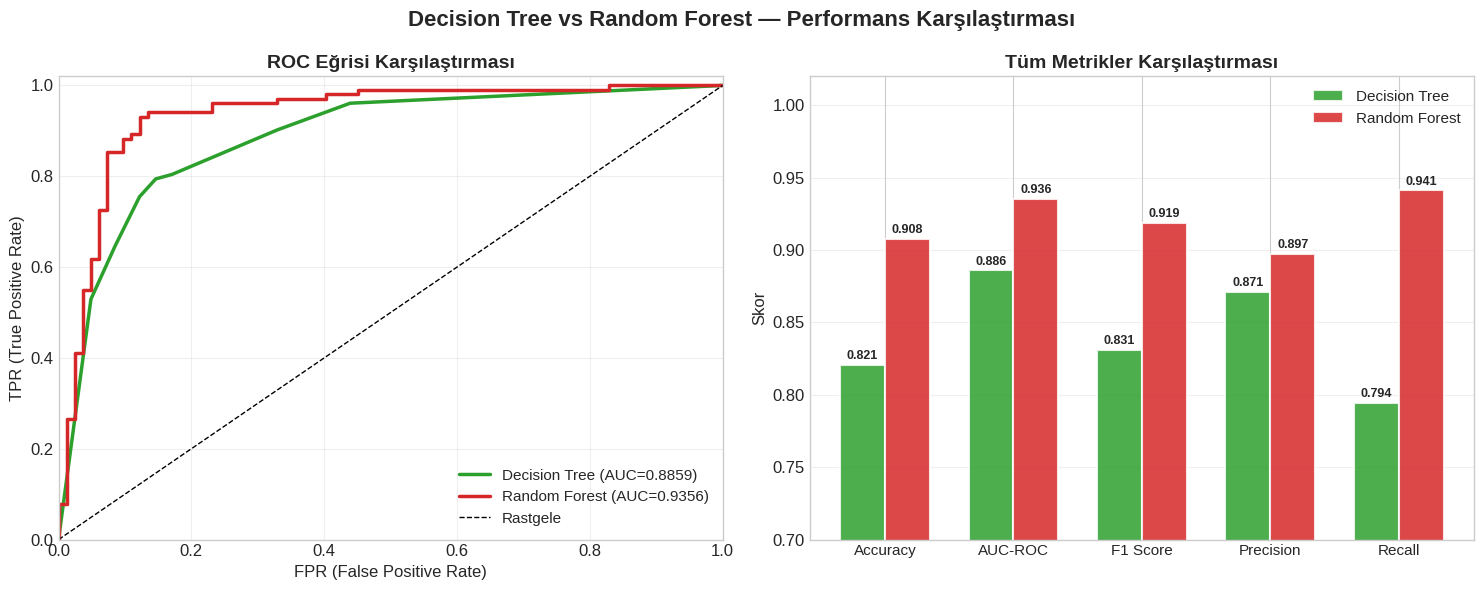

In [42]:
# ─── ROC Eğrisi + Metrik Bar Grafiği Karşılaştırması ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Sol: ROC Eğrisi ──────────────────────────────────────────────────────────
for prob, label, color, auc in [
    (dt_prob, 'Decision Tree', '#2ca02c', dt_auc),
    (rf_prob,  'Random Forest', '#d62728', rf_auc)
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    axes[0].plot(fpr, tpr, color=color, linewidth=2.5,
                 label=f'{label} (AUC={auc:.4f})')

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Rastgele')
axes[0].set_xlim([0, 1]); axes[0].set_ylim([0, 1.02])
axes[0].set_xlabel('FPR (False Positive Rate)', fontsize=12)
axes[0].set_ylabel('TPR (True Positive Rate)',  fontsize=12)
axes[0].set_title('ROC Eğrisi Karşılaştırması', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# ── Sağ: Tüm Metrikler Bar Grafiği ───────────────────────────────────────────
metrics    = ['Accuracy', 'AUC-ROC', 'F1 Score', 'Precision', 'Recall']
dt_scores = [dt_acc, dt_auc, dt_f1, dt_prec, dt_recall]
rf_scores  = [rf_acc,  rf_auc,  rf_f1,  rf_prec,  rf_recall]

x = np.arange(len(metrics))
width = 0.35

bars1 = axes[1].bar(x - width/2, dt_scores, width, label='Decision Tree',
                     color='#2ca02c', alpha=0.85, edgecolor='white', linewidth=1.5)
bars2 = axes[1].bar(x + width/2, rf_scores, width, label='Random Forest',
                     color='#d62728', alpha=0.85, edgecolor='white', linewidth=1.5)

for bar in list(bars1) + list(bars2):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.002,
                 f'{bar.get_height():.3f}', ha='center', va='bottom',
                 fontsize=9, fontweight='bold')

axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics, fontsize=11)
axes[1].set_ylabel('Skor', fontsize=12)
axes[1].set_title('Tüm Metrikler Karşılaştırması', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].set_ylim(0.7, 1.02) # Y ekseni aralığını ayarladım
axes[1].grid(True, axis='y', alpha=0.3)

plt.suptitle('Decision Tree vs Random Forest — Performans Karşılaştırması',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


🔄 5-Fold Cross Validation...
🌳 Decision Tree CV: [0.9022 0.8587 0.8043 0.7923 0.7213] → Ort: 0.8158 ± 0.0615
🌲 Random Forest  CV: [0.8804 0.8261 0.8424 0.847  0.7486] → Ort: 0.8289 ± 0.0439


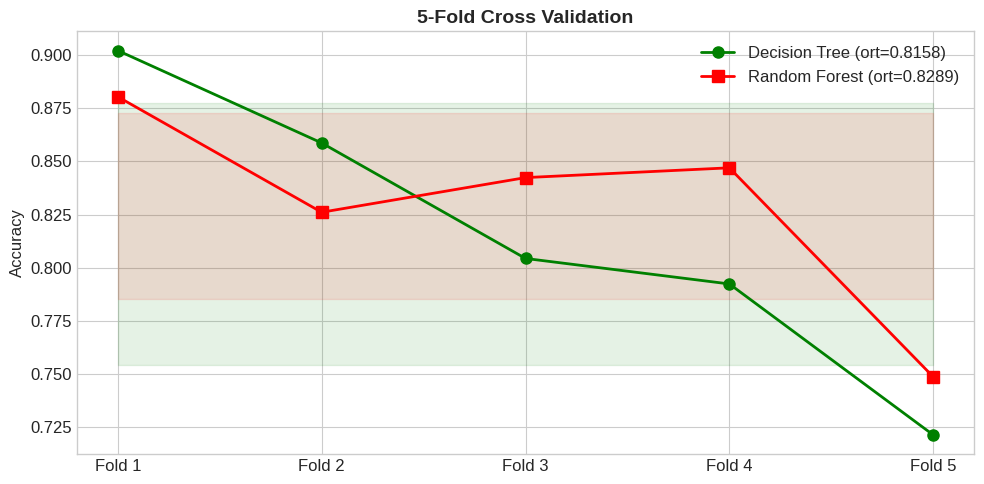

In [43]:
# ─── 5-Fold Cross Validation ────────────────────────────────────────────────
# Tek bir train/test bölmesi şansa bağlı olabilir.
# CV: veriyi 5 eşit parçaya böler, her seferinde 1 parça test kalanlar eğitim.
# Sonuç: 5 farklı skor → ortalama ve std ile daha güvenilir performans tahmini.

print('🔄 5-Fold Cross Validation...')
print('='*45)

# Decision Tree ve Random Forest için Pipeline oluşturmaya gerek yok
# çünkü ölçekleme bu modeller için zorunlu değil ve direkt ham veri kullanılabilir.

dt_cv = cross_val_score(DecisionTreeClassifier(max_depth=best_dt_depth, random_state=42), X, y, cv=5, scoring='accuracy')
rf_cv = cross_val_score(RandomForestClassifier(n_estimators=best_rf_n_estimators, max_depth=best_rf_max_depth, random_state=42), X, y, cv=5, scoring='accuracy')

print(f'🌳 Decision Tree CV: {dt_cv.round(4)} → Ort: {dt_cv.mean():.4f} ± {dt_cv.std():.4f}')
print(f'🌲 Random Forest  CV: {rf_cv.round(4)} → Ort: {rf_cv.mean():.4f} ± {rf_cv.std():.4f}')

# ─── CV görselleştir ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
x_fold = np.arange(5)

ax.plot(x_fold, dt_cv, 'o-', color='green', markersize=8, linewidth=2,
        label=f'Decision Tree (ort={dt_cv.mean():.4f})')
ax.plot(x_fold, rf_cv, 's-', color='red', markersize=8, linewidth=2,
        label=f'Random Forest (ort={rf_cv.mean():.4f})')

ax.fill_between(x_fold,
                dt_cv.mean() - dt_cv.std(),
                dt_cv.mean() + dt_cv.std(),
                alpha=0.1, color='green')
ax.fill_between(x_fold,
                rf_cv.mean() - rf_cv.std(),
                rf_cv.mean() + rf_cv.std(),
                alpha=0.1, color='red')

ax.set_xticks(x_fold)
ax.set_xticklabels([f'Fold {i+1}' for i in range(5)])
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('5-Fold Cross Validation', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()


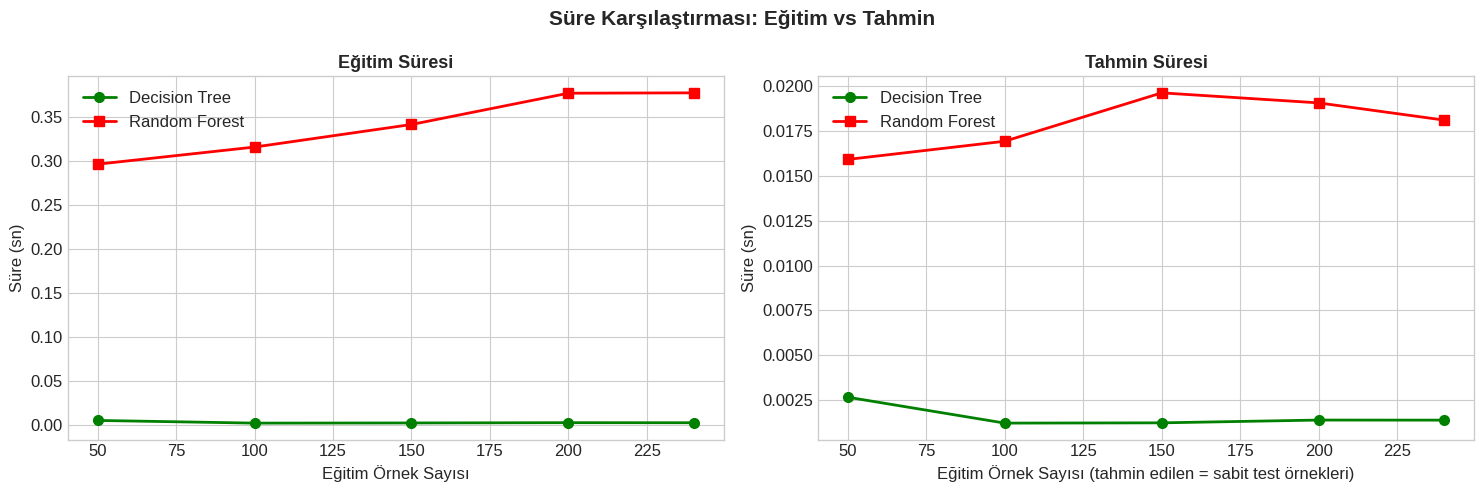

In [44]:
# ─── Farklı Veri Boyutlarında Eğitim & Tahmin Süresi ───────────────────────
# Karar Ağaçları ve Random Forest'ın hız farkı veri büyüdükçe nasıl değişiyor?

sizes = [50, 100, 150, 200, 240]   # Farklı eğitim boyutları (maksimum ~240 = %80 veri)
dt_train_times, rf_train_times = [], []
dt_pred_times,  rf_pred_times  = [], []

for s in sizes:
    Xs    = X_train.iloc[:s]
    ys    = y_train.iloc[:s]

    # ── Decision Tree eğitim süresi ──
    m_dt = DecisionTreeClassifier(max_depth=best_dt_depth, random_state=42)
    t = time.time()
    m_dt.fit(Xs, ys)
    dt_train_times.append(time.time() - t)

    # ── Decision Tree tahmin süresi ──
    t = time.time()
    m_dt.predict(X_test)
    dt_pred_times.append(time.time() - t)

    # ── Random Forest eğitim süresi ──
    m_rf = RandomForestClassifier(n_estimators=best_rf_n_estimators, max_depth=best_rf_max_depth, random_state=42)
    t = time.time()
    m_rf.fit(Xs, ys)
    rf_train_times.append(time.time() - t)

    # ── Random Forest tahmin süresi ──
    t = time.time()
    m_rf.predict(X_test)
    rf_pred_times.append(time.time() - t)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Sol: Eğitim süresi karşılaştırması
axes[0].plot(sizes, dt_train_times, 'o-', color='green', markersize=7, linewidth=2, label='Decision Tree')
axes[0].plot(sizes, rf_train_times, 's-', color='red', markersize=7, linewidth=2, label='Random Forest')
axes[0].set_title('Eğitim Süresi', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Eğitim Örnek Sayısı')
axes[0].set_ylabel('Süre (sn)')
axes[0].legend()

# Sağ: Tahmin süresi karşılaştırması
axes[1].plot(sizes, dt_pred_times, 'o-', color='green', markersize=7, linewidth=2, label='Decision Tree')
axes[1].plot(sizes, rf_pred_times, 's-', color='red', markersize=7, linewidth=2, label='Random Forest')
axes[1].set_title('Tahmin Süresi', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Eğitim Örnek Sayısı (tahmin edilen = sabit test örnekleri)')
axes[1].set_ylabel('Süre (sn)')
axes[1].legend()

plt.suptitle('Süre Karşılaştırması: Eğitim vs Tahmin', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


## 9. Nihai Sonuç Tablosu

In [45]:
# ─── Tüm Metrikleri Tek Tabloda Özetle ─────────────────────────────────────
# Her metrik için kazananı otomatik olarak belirle

results_df = pd.DataFrame({
    'Metrik': ['Accuracy', 'AUC-ROC', 'F1 Score', 'Precision', 'Recall',
               'CV Ortalama', 'CV Std', 'Eğitim Süresi (sn)', 'Tahmin Süresi (sn)'],
    'Decision Tree 🌳': [
        f'{dt_acc:.4f}',        f'{dt_auc:.4f}',
        f'{dt_f1:.4f}',         f'{dt_prec:.4f}',
        f'{dt_recall:.4f}',     f'{dt_cv.mean():.4f}',
        f'{dt_cv.std():.4f}',   f'{dt_train_time:.6f}',
        f'{dt_pred_time:.6f}'
    ],
    'Random Forest 🌲': [
        f'{rf_acc:.4f}',         f'{rf_auc:.4f}',
        f'{rf_f1:.4f}',          f'{rf_prec:.4f}',
        f'{rf_recall:.4f}',      f'{rf_cv.mean():.4f}',
        f'{rf_cv.std():.4f}',    f'{rf_train_time:.6f}',
        f'{rf_pred_time:.6f}'
    ],
    'Kazanan': [
        '🌳 Decision Tree' if dt_acc    >= rf_acc    else '🌲 Random Forest',
        '🌳 Decision Tree' if dt_auc    >= rf_auc    else '🌲 Random Forest',
        '🌳 Decision Tree' if dt_f1     >= rf_f1     else '🌲 Random Forest',
        '🌳 Decision Tree' if dt_prec   >= rf_prec   else '🌲 Random Forest',
        '🌳 Decision Tree' if dt_recall >= rf_recall else '🌲 Random Forest',
        '🌳 Decision Tree' if dt_cv.mean() >= rf_cv.mean() else '🌲 Random Forest',
        '🌳 Decision Tree' if dt_cv.std()  <= rf_cv.std()  else '🌲 Random Forest', # Düşük std daha iyi
        '🌳 Decision Tree' if dt_train_time <= rf_train_time else '🌲 Random Forest', # Kısa süre daha iyi
        '🌳 Decision Tree' if dt_pred_time <= rf_pred_time else '🌲 Random Forest'  # Kısa süre daha iyi
    ]
})

print('\n' + '='*70)
print('        📊 DECISION TREE vs RANDOM FOREST — SONUÇ TABLOSU')
print('='*70)
print(results_df.to_string(index=False))
print('='*70)

dt_wins = sum(1 for k in results_df['Kazanan'] if 'Decision Tree' in k)
rf_wins  = sum(1 for k in results_df['Kazanan'] if 'Random Forest' in k)
print(f'\n🏆 GENEL SONUÇ:')
print(f'   🌳 Decision Tree kazandı: {dt_wins}/{len(results_df)} kategoride')
print(f'   🌲 Random Forest kazandı: {rf_wins}/{len(results_df)} kategoride')



        📊 DECISION TREE vs RANDOM FOREST — SONUÇ TABLOSU
            Metrik Decision Tree 🌳 Random Forest 🌲         Kazanan
          Accuracy          0.8207          0.9076 🌲 Random Forest
           AUC-ROC          0.8859          0.9356 🌲 Random Forest
          F1 Score          0.8308          0.9187 🌲 Random Forest
         Precision          0.8710          0.8972 🌲 Random Forest
            Recall          0.7941          0.9412 🌲 Random Forest
       CV Ortalama          0.8158          0.8289 🌲 Random Forest
            CV Std          0.0615          0.0439 🌲 Random Forest
Eğitim Süresi (sn)        0.009362        0.547843 🌳 Decision Tree
Tahmin Süresi (sn)        0.003282        0.069318 🌳 Decision Tree

🏆 GENEL SONUÇ:
   🌳 Decision Tree kazandı: 2/9 kategoride
   🌲 Random Forest kazandı: 7/9 kategoride


---

## 10. Hangi Algoritmayı Kullanmalısınız?

### ✅ Decision Tree Kullanın — Eğer:
-   Modelin **yorumlanabilirliği** çok önemliyse.
-   Veri setinin yapısı **doğrusalsa** veya basit kurallarla ayrılabilirse.
-   Hızlı bir **baseline** modele ihtiyacınız varsa.
-   Küçük veri setlerinde çalışıyorsanız (overfitting riskini yöneterek).
-   Özellikler arası **etkileşimleri** görsel olarak anlamak istiyorsanız.

### ✅ Random Forest Kullanın — Eğer:
-   Daha **yüksek doğruluk** ve genelleme performansı arıyorsanız.
-   Tek bir Decision Tree'nin **overfitting** eğilimini azaltmak istiyorsanız.
-   Veri setinde **gürültü** veya aykırı değerler varsa (daha dayanıklıdır).
-   Özellikler arası **karmaşık ilişkileri** yakalamak istiyorsanız.
-   Daha az yorumlanabilirlik pahasına **robust (sağlam) bir model** tercih ediyorsanız.

---

## 11. Özet

| | Decision Tree | Random Forest |
|---|---|---|
| **En iyi durum** | Hızlı, yorumlanabilir, basit ilişkiler | Yüksek performans, karmaşık ilişkiler, gürültülü veri |
| **Güçlü yönü** | Anlaşılması kolay, özellik etkileşimlerini gösterir | Yüksek doğruluk, overfitting'e dirençli, özellik önemi |
| **Zayıf yönü** | Overfitting eğilimi, yüksek varyans | Daha yavaş, yorumlanması zor, siyah kutu |
| **Ölçekleme** | Gerekli değil | Gerekli değil |
| **Endüstri kullanımı** | Kural tabanlı sistemler, başlangıç modelleri | Tıbbi teşhis, müşteri segmentasyonu, finansal tahminler |

> 💡 Decision Tree hızlı ve yorumlanabilir bir başlangıç sağlarken, Random Forest genellikle daha yüksek performans ve sağlamlık sunar.
